### Data Loading & Exploration

In [2]:
import pandas as pd

# Read data 
data = pd.read_csv("dataset/data.csv")
data.head()

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [3]:
# Check class balance
data_real = data[data["label"] == 1]
data_fake = data[data["label"] == 0]
print(len(data_real), len(data_fake))

19999 19943


In [4]:
# Check NaN values
print(data.isnull().sum())

label      0
title      0
text       0
subject    0
date       0
dtype: int64


In [6]:
# Check duplicates
data.duplicated().sum()

np.int64(201)

In [7]:
# Drop duplicates
data_cleaned = data.drop_duplicates()
data_cleaned = data_cleaned.reset_index(drop=True)

### Data Cleaning

In [8]:
# Import data cleaning function
from text_utils import clean_data

# Clean the data
data_cleaned["title"] = data_cleaned["title"].apply(clean_data)
data_cleaned["text"] = data_cleaned["text"].apply(clean_data)
data_cleaned["subject"] = data_cleaned["subject"].apply(clean_data)
data_cleaned.head()

,label,title,text,subject,date
0,1,as us budget fight looms republicans flip thei...,washington reuters the head of a conservative...,politicsnews,"December 31, 2017"
1,1,us military to accept transgender recruits on ...,washington reuters transgender people will be...,politicsnews,"December 29, 2017"
2,1,senior us republican senator let mr mueller do...,washington reuters the special counsel invest...,politicsnews,"December 31, 2017"
3,1,fbi russia probe helped by australian diplomat...,washington reuters trump campaign adviser geo...,politicsnews,"December 30, 2017"
4,1,trump wants postal service to charge much more...,seattlewashington reuters president donald tr...,politicsnews,"December 29, 2017"


In [9]:
# Drop irrelevant columns
data_cleaned.drop(["subject", "date"], axis=1, inplace=True)

In [10]:
# Combine title and text into one column
data_cleaned["full_content"] = data_cleaned["title"] + " " + data_cleaned["text"]
data_cleaned.drop(["title", "text"], axis=1, inplace=True)
data_cleaned

,label,full_content
0,1,as us budget fight looms republicans flip thei...
1,1,us military to accept transgender recruits on ...
2,1,senior us republican senator let mr mueller do...
3,1,fbi russia probe helped by australian diplomat...
4,1,trump wants postal service to charge much more...
...,...,...
39736,0,this is not a joke soroslinked group has plan ...
39737,0,the smartest woman in politics “how trump can ...
39738,0,breaking shocking video from charlotte riots “...
39739,0,breaking charlotte news station reports cops h...


### Data Pre-Processing

In [11]:
# Import pre-processing function
from text_utils import preprocess_data

# Apply and store final data (join content back into a single string to match format expected by TF-IDF) 
data_final = data_cleaned.copy()
data_final["full_content"] = data_final["full_content"].apply(preprocess_data).apply(lambda x: " ".join(x))

print(data_final.iloc[0]["full_content"])

budget fight loom republican flip fiscal script washington head conservative republican faction congress voted month huge expansion national debt pay tax cut called fiscal conservative sunday urged budget restraint keeping sharp pivot way among republican representative mark meadow speaking cbs face nation drew hard line federal spending lawmaker bracing battle january return holiday wednesday lawmaker begin trying pas federal budget fight likely linked issue immigration policy even november congressional election campaign approach republican seek keep control congress president donald trump republican want big budget increase military spending democrat also want proportional increase nondefense discretionary spending program support education scientific research infrastructure public health environmental protection trump administration already willing say going increase nondefense discretionary spending percent meadow chairman small influential house freedom caucus said program democr

In [12]:
# Train test split 
from sklearn.model_selection import train_test_split

# Extract X and y 
X = data_final["full_content"]
y = data_final["label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Feature Extraction

#### TF-IDF

In [13]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### Model Training & Evaluation

In [14]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3970
           1       0.98      0.98      0.98      3979

    accuracy                           0.98      7949
   macro avg       0.98      0.98      0.98      7949
weighted avg       0.98      0.98      0.98      7949



#### Confusion matrix

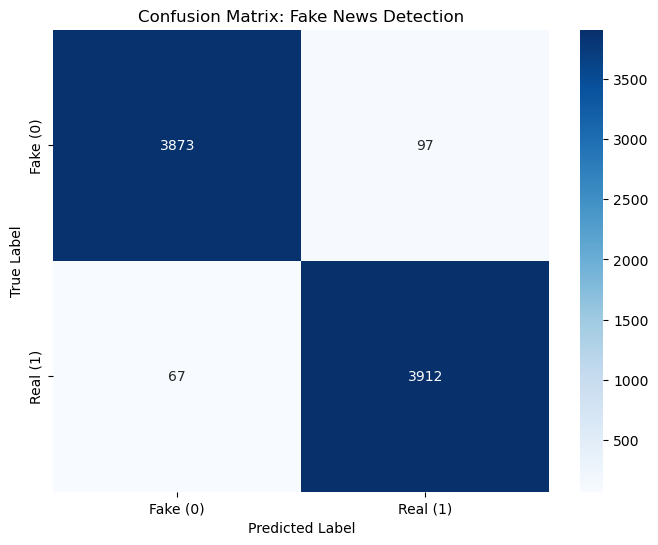

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate the raw matrix data
cm = confusion_matrix(y_test, y_pred)

# 2. Set up the figure
plt.figure(figsize=(8, 6))

# 3. Create the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake (0)', 'Real (1)'], 
            yticklabels=['Fake (0)', 'Real (1)'])

# 4. Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Fake News Detection')
plt.show()

#### Checking coefficients

In [16]:
# Get the words from the vectorizer
feature_names = tfidf.get_feature_names_out()

# Get the weights from the model
weights = model.coef_[0]

# Create a DataFrame to view them
df_weights = pd.DataFrame({'word': feature_names, 'weight': weights})

print("--- Top 10 'REAL' Words ---")
print(df_weights.sort_values(by='weight', ascending=False).head(10))

print("\n--- Top 10 'FAKE' Words ---")
print(df_weights.sort_values(by='weight', ascending=True).head(10))

--- Top 10 'REAL' Words ---
              word     weight
3903          said  19.735656
4857    washington   8.511963
4879     wednesday   5.771177
4650       tuesday   5.739421
4534      thursday   5.255023
1852        friday   5.254267
2896        monday   4.565154
3410  presidential   4.415287
1438           edt   4.063475
3040           nov   3.999591

--- Top 10 'FAKE' Words ---
          word     weight
4790     video -10.708415
2206     image  -9.112548
4786       via  -8.973525
1941       gop  -6.654260
2102   hillary  -5.749184
2929        mr  -5.125871
1576      even  -5.081395
2635      like  -4.512968
567   breaking  -4.216073
4859     watch  -4.130811


### Final Predictions

In [17]:
# Read validation data 
data_val = pd.read_csv("dataset/validation_data.csv")

In [18]:
# Clean the data 
data_val_cleaned = data_val.copy()
data_val_cleaned["title"] = data_val_cleaned["title"].apply(clean_data)
data_val_cleaned["text"] = data_val_cleaned["text"].apply(clean_data)
data_val_cleaned["subject"] = data_val_cleaned["subject"].apply(clean_data)
data_val_cleaned.head()

,label,title,text,subject,date
0,2,uks may receiving regular updates on london tu...,london reuters british prime minister theresa...,worldnews,"September 15, 2017"
1,2,uk transport police leading investigation of l...,london reuters british counterterrorism polic...,worldnews,"September 15, 2017"
2,2,pacific nations crack down on north korean shi...,wellington reuters south pacific island natio...,worldnews,"September 15, 2017"
3,2,three suspected al qaeda militants killed in y...,aden yemen reuters three suspected al qaeda m...,worldnews,"September 15, 2017"
4,2,chinese academics prod beijing to consider nor...,beijing reuters chinese academics are publicl...,worldnews,"September 15, 2017"


In [19]:
# Drop irrelevant columns
data_val_cleaned.drop(["subject", "date"], axis=1, inplace=True)

In [20]:
# Combine title and text into one column
data_val_cleaned["full_content"] = data_val_cleaned["title"] + " " + data_val_cleaned["text"]
data_val_cleaned.drop(["title", "text"], axis=1, inplace=True)
data_val_cleaned

,label,full_content
0,2,uks may receiving regular updates on london tu...
1,2,uk transport police leading investigation of l...
2,2,pacific nations crack down on north korean shi...
3,2,three suspected al qaeda militants killed in y...
4,2,chinese academics prod beijing to consider nor...
...,...,...
4951,2,mcpain john mccain furious that iran treated u...
4952,2,justice yahoo settles email privacy classactio...
4953,2,sunnistan us and allied ‘safe zone’ plan to ta...
4954,2,how to blow million al jazeera america finall...


In [21]:
# Apply and store final data (join content back into a single string to match format expected by TF-IDF) 
data_val_final = data_val_cleaned.copy()
data_val_final["full_content"] = data_val_final["full_content"].apply(preprocess_data).apply(lambda x: " ".join(x))

data_val_final.head(10)

,label,full_content
0,2,uk may receiving regular update london tube st...
1,2,uk transport police leading investigation lond...
2,2,pacific nation crack north korean ship fiji pr...
3,2,three suspected al qaeda militant killed yemen...
4,2,chinese academic prod beijing consider north k...
5,2,flame raced along train west london station ey...
6,2,london police advise people avoid area near st...
7,2,london ambulance service sends hazardous area ...
8,2,witness say injured stampede london station re...
9,2,uk say world stand together north korea missil...


In [28]:
# TF-IDF
X_val_tfidf = tfidf.transform(data_val_final['full_content'])

# Predict using the Logistic Regression
val_predictions = model.predict(X_val_tfidf)

# Assign labels and save the file 
final_submission = data_val.copy()
final_submission['label'] = val_predictions
final_columns = ['label', 'title', 'text', 'subject', 'date']
final_submission = final_submission[final_columns]
final_submission.to_csv('final_submission.csv', 
                        sep=',', 
                        index=False, 
                        encoding='utf-8')